# Spatial-only PAD Baseline — Optimized Runtime-aligned Protocol v5

Notebook này triển khai **E1 Spatial-only MobileNetV3-Large** với protocol sạch của v4 và một số tối ưu training **không thay đổi research question**:

- Train / Validation / Test tách biệt;
- **Train và Validation subject-disjoint**, đồng thời loại mọi subject overlap với official Test mirror trước khi split;
- `RUN_MODE="preliminary"`: Train 100K + Val ~15K; `RUN_MODE="official"`: dùng toàn bộ clean Train pool còn lại với cùng Validation subjects;
- crop vuông mở rộng 1.5× và resize khớp `antispoof/preprocess.py` runtime;
- mild augmentation chỉ ở Train; không blur/JPEG/erase/rotation/perspective;
- **không áp Adaptive Gamma** trong train/validation/test research protocol;
- 3-class training (`Real / Physical Spoof / Digital Spoof`), binary PAD score khớp production predictor:
  `pad_score = real_logit - logsumexp(all_spoof_logits)`;
- checkpoint chọn theo **Validation ACER**, threshold calibrate trên Validation và khóa trước Test;
- **Batch size 128** để giữ throughput gần v4; không đánh đổi ~2× thời gian chỉ để tăng stochasticity;
- **2-epoch LR warmup + cosine decay theo cùng một multiplicative factor**, giữ tỷ lệ LR backbone:head = 1:10 trong toàn bộ training;
- tối đa **24 epochs + early stopping theo Validation ACER**: worst-case chỉ ~20% nhiều epoch hơn v4, thường dừng sớm;
- **gradient clipping** sau AMP unscale để bảo vệ khỏi gradient spike;
- held-out Test **không tự chạy mặc định** (`RUN_HELDOUT_TEST=False`) để tránh human test-set tuning;
- lưu best PyTorch state + resume checkpoint, export ONNX + parity check.

> Các tối ưu v5 là **expected-to-help training stability/generalization, không phải bảo đảm metric sẽ cao hơn trước khi chạy**. Nếu dùng E3 sau này, phải tái sử dụng cùng split và cùng training recipe v5 để comparison công bằng.

> **Gamma policy:** baseline khoa học dùng `apply_gamma=False`. Nếu production muốn gamma, hãy calibrate một deployment threshold riêng trên Validation bằng đúng gamma preprocessing.

> **Quan trọng:** Không resume từ checkpoint v1–v5.0. Protocol v5 từ chối checkpoint không tương thích.

> **Time-balanced v5.1:** preliminary 100K dùng batch 128, tối đa 24 epochs, patience 4 (không early-stop trước epoch 10). So với v4 20 epochs × batch 128, worst-case optimizer-step budget chỉ tăng khoảng 20%, không còn mức ~3× của v5 ban đầu.


In [1]:
# Cell 1: Libraries, reproducibility & environment
!pip install -q albumentations onnx onnxruntime scikit-learn

import os, json, time, sys, random, copy, shutil, hashlib, math
from pathlib import PurePosixPath

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import torchvision
import torchvision.models as models
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GroupShuffleSplit
import matplotlib.pyplot as plt

try:
    import onnx
    import onnxruntime as ort
    ONNX_AVAILABLE = True
except ModuleNotFoundError:
    ONNX_AVAILABLE = False
    print("⚠️ onnx/onnxruntime chưa có. Training vẫn chạy được; cài trước Cell Export ONNX.")

# ---------------- Reproducibility ----------------
SAMPLE_SEED = 42
random.seed(SAMPLE_SEED)
np.random.seed(SAMPLE_SEED)
torch.manual_seed(SAMPLE_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SAMPLE_SEED)

# Exact split/config/seed remain reproducible. Bitwise deterministic CUDA kernels are optional
# because they can materially slow fixed-shape 224x224 convolution training.
STRICT_DETERMINISM = False
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = STRICT_DETERMINISM
    torch.backends.cudnn.benchmark = not STRICT_DETERMINISM
else:
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = False


def safe_torch_load(path, map_location="cpu", *, weights_only=None):
    """Compatibility wrapper for PyTorch versions before/after weights_only became available/default."""
    kwargs = {"map_location": map_location}
    if weights_only is not None:
        kwargs["weights_only"] = weights_only
    try:
        return torch.load(path, **kwargs)
    except TypeError:
        kwargs.pop("weights_only", None)
        return torch.load(path, **kwargs)


print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Albumentations:", A.__version__)
print("OpenCV:", cv2.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("Strict CUDA determinism:", STRICT_DETERMINISM)
print("cuDNN benchmark:", torch.backends.cudnn.benchmark)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 13.9 MB/s eta 0:00:00
Python: 3.12.13
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Albumentations: 2.0.8
OpenCV: 4.13.0
CUDA Available: True
Strict CUDA determinism: False
cuDNN benchmark: True
GPU: Tesla T4


# Cell 2: Dataset Definition — CelebA-Spoof 3 classes

**Label mapping:** `0 = Real`, `1 = Physical Spoof`, `2 = Digital Spoof`.

Dataset loader đọc ảnh bằng OpenCV **BGR**, chuyển bbox CelebA-Spoof sang `xyxy`, rồi gọi crop tương đương runtime: square crop mở rộng **1.5×** + `BORDER_REFLECT_101`. Sau crop mới đổi **BGR → RGB** cho MobileNetV3.

Adaptive Gamma **không nằm trong dataset training/validation/test của research baseline**. Nếu cần gamma ở deployment, calibrate một inference profile riêng sau khi model đã khóa.

Với research run, lỗi ảnh/bbox sẽ **fail fast** thay vì âm thầm thay bằng ảnh đen hoặc full image.


In [2]:
BBOX_EXPANSION_FACTOR = 1.5
# Mild detector-geometry augmentation: only 20% of training samples are jittered.
# 80% therefore use the exact runtime crop geometry.
BBOX_JITTER_P = 0.20
BBOX_JITTER_SCALE = (0.95, 1.05)
BBOX_JITTER_TRANSLATE = 0.05
STRICT_DATA = True
RESEARCH_APPLY_GAMMA = False
assert RESEARCH_APPLY_GAMMA is False, "Gamma must not be part of the baseline training/evaluation pipeline."


def label_of(meta_value):
    """Map CelebA-Spoof detailed attack type at index 40 -> 3-class label."""
    if len(meta_value) <= 40:
        raise ValueError(f"Metadata entry too short: len={len(meta_value)}")
    raw = int(meta_value[40])
    if raw == 0:
        return 0  # Real
    if raw in [1, 2, 3, 4, 5, 6, 7]:
        return 1  # Physical spoof
    return 2      # Digital spoof


def subject_id_from_relpath(rel_path):
    """Extract subject id from paths such as Data/train/2623/live/000000.jpg."""
    parts = PurePosixPath(rel_path.replace('\\', '/')).parts
    for i, part in enumerate(parts[:-1]):
        if part.lower() in {"train", "test"} and i + 1 < len(parts):
            return parts[i + 1]
    raise ValueError(f"Cannot infer subject id from path: {rel_path}")


def runtime_crop_bgr(img, bbox_xyxy, bbox_expansion_factor=BBOX_EXPANSION_FACTOR):
    """
    Exact training-side clone of antispoof/preprocess.py::crop() semantics.
    Input/output remain BGR; gamma is intentionally NOT applied here.
    """
    original_height, original_width = img.shape[:2]
    x1, y1, x2, y2 = bbox_xyxy
    w = x2 - x1
    h = y2 - y1
    if w <= 0 or h <= 0:
        raise ValueError(f"Invalid xyxy bbox: {bbox_xyxy}")

    max_dim = max(w, h)
    center_x = x1 + w / 2
    center_y = y1 + h / 2

    x_start = int(center_x - max_dim * bbox_expansion_factor / 2)
    y_start = int(center_y - max_dim * bbox_expansion_factor / 2)
    crop_size = int(max_dim * bbox_expansion_factor)
    if crop_size <= 0:
        raise ValueError(f"Invalid crop_size={crop_size} for bbox={bbox_xyxy}")

    crop_x1 = max(0, x_start)
    crop_y1 = max(0, y_start)
    crop_x2 = min(original_width, x_start + crop_size)
    crop_y2 = min(original_height, y_start + crop_size)

    top_pad = int(max(0, -y_start))
    left_pad = int(max(0, -x_start))
    bottom_pad = int(max(0, (y_start + crop_size) - original_height))
    right_pad = int(max(0, (x_start + crop_size) - original_width))

    if crop_x2 > crop_x1 and crop_y2 > crop_y1:
        cropped_img = img[crop_y1:crop_y2, crop_x1:crop_x2, :]
    else:
        cropped_img = np.zeros((0, 0, 3), dtype=img.dtype)

    result = cv2.copyMakeBorder(
        cropped_img,
        top_pad, bottom_pad, left_pad, right_pad,
        cv2.BORDER_REFLECT_101,
    )

    if result.shape[0] != crop_size or result.shape[1] != crop_size:
        result = cv2.resize(result, (crop_size, crop_size), interpolation=cv2.INTER_AREA)
    return result


def read_expanded_face_crop_rgb(
    img_path, expansion_factor=BBOX_EXPANSION_FACTOR, strict=True,
    bbox_jitter=False, bbox_jitter_p=BBOX_JITTER_P,
    jitter_scale=BBOX_JITTER_SCALE, jitter_translate=BBOX_JITTER_TRANSLATE,
):
    """
    Read BGR image -> optional Train-only bbox jitter -> runtime-compatible crop -> RGB.
    Bbox jitter perturbs detector geometry WITHOUT an extra affine image resampling step.
    """
    image_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if image_bgr is None:
        if strict:
            raise FileNotFoundError(f"Cannot read image: {img_path}")
        return None

    h_img, w_img = image_bgr.shape[:2]
    bb_path = os.path.splitext(img_path)[0] + "_BB.txt"
    if not os.path.exists(bb_path):
        if strict:
            raise FileNotFoundError(f"Missing bbox file: {bb_path}")
        return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    try:
        with open(bb_path, 'r') as f:
            parts = f.readline().strip().split()
        if len(parts) < 4:
            raise ValueError(f"bbox needs >=4 values, got {parts}")
        x, y, w, h = map(float, parts[:4])
    except (OSError, ValueError) as exc:
        if strict:
            raise RuntimeError(f"Invalid bbox file {bb_path}: {exc}") from exc
        return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # CelebA-Spoof BB coordinates use a 224-reference coordinate system.
    x = x / 224.0 * w_img
    y = y / 224.0 * h_img
    w = w / 224.0 * w_img
    h = h / 224.0 * h_img
    if w <= 0 or h <= 0:
        raise ValueError(f"Non-positive bbox at {bb_path}: {(x, y, w, h)}")

    if bbox_jitter and random.random() < float(bbox_jitter_p):
        # Detector-like geometric perturbation on a minority of samples only:
        # scale 0.95–1.05, center translation ±5% of face size.
        base = max(w, h)
        cx = x + w / 2.0
        cy = y + h / 2.0
        scale = random.uniform(float(jitter_scale[0]), float(jitter_scale[1]))
        cx += random.uniform(-jitter_translate, jitter_translate) * base
        cy += random.uniform(-jitter_translate, jitter_translate) * base
        w *= scale
        h *= scale
        x = cx - w / 2.0
        y = cy - h / 2.0

    crop_bgr = runtime_crop_bgr(
        image_bgr,
        (x, y, x + w, y + h),
        bbox_expansion_factor=expansion_factor,
    )
    if crop_bgr.size == 0:
        raise RuntimeError(f"Empty crop for {img_path}; bbox={bb_path}")
    return cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)


def runtime_preprocess_rgb(img_rgb, model_img_size, mean, std):
    """
    Match preprocess.py after BGR->RGB when apply_gamma=False:
    aspect-preserving resize, REFLECT_101 letterbox, /255, mean/std, HWC->CHW tensor.
    """
    if img_rgb is None or img_rgb.size == 0:
        raise ValueError("Cannot preprocess an empty image")

    new_size = int(model_img_size)
    old_size = img_rgb.shape[:2]
    ratio = float(new_size) / max(old_size)
    scaled_shape = tuple(int(x * ratio) for x in old_size)
    interpolation = cv2.INTER_LANCZOS4 if ratio > 1.0 else cv2.INTER_AREA
    img = cv2.resize(img_rgb, (scaled_shape[1], scaled_shape[0]), interpolation=interpolation)

    delta_w = new_size - scaled_shape[1]
    delta_h = new_size - scaled_shape[0]
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_REFLECT_101)

    arr = img.transpose(2, 0, 1).astype(np.float32) / 255.0
    if mean is not None and std is not None:
        mean_arr = np.asarray(mean, dtype=np.float32).reshape(3, 1, 1)
        std_arr = np.asarray(std, dtype=np.float32).reshape(3, 1, 1)
        arr = (arr - mean_arr) / std_arr
    return torch.from_numpy(np.ascontiguousarray(arr))


class CelebASpoof3ClassDataset(Dataset):
    def __init__(
        self, root_dir, json_path, keys=None, augment_transform=None,
        model_img_size=224, mean=None, std=None, bbox_jitter=False,
        bbox_jitter_p=0.0, strict=STRICT_DATA
    ):
        self.root_dir = root_dir
        self.json_path = json_path
        with open(json_path, 'r') as f:
            self.data = json.load(f)
        self.keys = list(self.data.keys()) if keys is None else list(keys)
        self.augment_transform = augment_transform
        self.model_img_size = int(model_img_size)
        self.mean = mean
        self.std = std
        self.bbox_jitter = bool(bbox_jitter)
        self.bbox_jitter_p = float(bbox_jitter_p)
        if not 0.0 <= self.bbox_jitter_p <= 1.0:
            raise ValueError(f"bbox_jitter_p must be in [0,1], got {self.bbox_jitter_p}")
        self.strict = strict

        missing = [k for k in self.keys if k not in self.data]
        if missing:
            raise KeyError(f"{len(missing)} selected keys are not present in {json_path}")

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        rel_path = self.keys[idx]
        meta_value = self.data[rel_path]
        img_path = os.path.join(self.root_dir, rel_path)

        image_rgb = read_expanded_face_crop_rgb(
            img_path,
            expansion_factor=BBOX_EXPANSION_FACTOR,
            strict=self.strict,
            bbox_jitter=self.bbox_jitter,
            bbox_jitter_p=self.bbox_jitter_p,
        )
        label = label_of(meta_value)

        # Augmentation is Train-only and happens before final runtime-aligned resize/normalize.
        if self.augment_transform is not None:
            image_rgb = self.augment_transform(image=image_rgb)['image']

        image_tensor = runtime_preprocess_rgb(
            image_rgb,
            model_img_size=self.model_img_size,
            mean=self.mean,
            std=self.std,
        )
        return image_tensor, torch.tensor(label, dtype=torch.long)


# Cell 3: Clean Train / Validation / Test split + Mild Augmentation

- `train_label.json` → loại subject overlap với official Test → **subject-group split** thành Train pool + Validation;
- Validation target khoảng 15K ảnh và chọn trong nhiều group splits để giữ class proportions gần clean train;
- `RUN_MODE="preliminary"` lấy 100K ảnh stratified từ Train pool;
- `RUN_MODE="official"` dùng toàn bộ Train pool còn lại nhưng **giữ nguyên Validation subject split**;
- `test_label.json` → held-out Test only;
- **Train subjects ∩ Val subjects ∩ Test subjects = ∅**;
- Validation/Test không augmentation và không gamma.

Main augmentation vẫn cố ý nhẹ:

```text
HorizontalFlip p=0.5
Brightness/Contrast ±10%, p=0.30
BBox detector-like jitter p=0.20 (scale 0.95–1.05, translation ±5%)
```

Không thêm blur/JPEG/erase/mixup/cutmix vì các phép đó có thể phá hoặc tự tạo low-level spoof cues.


In [3]:
# Cell 3: Transforms & DataLoaders — runtime-aligned clean 3-way protocol
CELEBA_MEAN = [0.5931, 0.4690, 0.4229]
CELEBA_STD = [0.2471, 0.2214, 0.2157]

INPUT_SIZE = 224
RUN_MODE = "preliminary"  # "preliminary" or "official"
VAL_SAMPLE_SIZE = 15_000      # Target; actual can differ slightly because split is subject-disjoint.
if RUN_MODE == "preliminary":
    TRAIN_SAMPLE_SIZE = 100_000
    TEST_SAMPLE_SIZE = 10_000
elif RUN_MODE == "official":
    TRAIN_SAMPLE_SIZE = None   # Use every remaining clean train-pool image.
    TEST_SAMPLE_SIZE = None    # Full official Test, but evaluation is still gated later.
else:
    raise ValueError(f"Unknown RUN_MODE={RUN_MODE!r}; use 'preliminary' or 'official'.")

BATCH_SIZE = 128
NUM_WORKERS = 4


# Train appearance augmentation only. Geometric scale/translation is implemented as bbox jitter
# before crop, avoiding an extra affine resampling that could create synthetic frequency artifacts.
# IMPORTANT: bbox jitter itself is applied with p=0.20, not to every sample.
# Final resize/normalize is performed by Dataset with runtime semantics.
train_augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.10,
        contrast_limit=0.10,
        p=0.30,
    ),
])

# Validation/Test use augment_transform=None: crop -> runtime resize -> RGB normalize only.

DATA_ROOT = "/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof"
TRAIN_JSON = os.path.join(DATA_ROOT, "metas/intra_test/train_label.json")
TEST_JSON = os.path.join(DATA_ROOT, "metas/intra_test/test_label.json")

with open(TRAIN_JSON, 'r') as f:
    train_meta = json.load(f)
with open(TEST_JSON, 'r') as f:
    test_meta = json.load(f)

all_train_keys = np.array(list(train_meta.keys()), dtype=object)
all_test_keys = np.array(list(test_meta.keys()), dtype=object)

# -------- Remove subject overlap with official Test BEFORE any Train/Val split --------
train_subjects = {subject_id_from_relpath(k) for k in all_train_keys}
test_subjects = {subject_id_from_relpath(k) for k in all_test_keys}
overlap_subjects = train_subjects & test_subjects

clean_train_keys = np.array(
    [k for k in all_train_keys if subject_id_from_relpath(k) not in overlap_subjects],
    dtype=object,
)
removed_overlap_samples = len(all_train_keys) - len(clean_train_keys)

print(f"Train metadata: {len(all_train_keys):,} samples / {len(train_subjects):,} subjects")
print(f"Test metadata : {len(all_test_keys):,} samples / {len(test_subjects):,} subjects")
print(f"Subject overlap detected: {len(overlap_subjects)} subjects -> removed {removed_overlap_samples:,} train samples")
if overlap_subjects:
    print("Overlap subject IDs:", sorted(overlap_subjects))

clean_subjects = np.array([subject_id_from_relpath(k) for k in clean_train_keys], dtype=object)
clean_labels = np.array([label_of(train_meta[k]) for k in clean_train_keys], dtype=np.int64)
assert set(clean_subjects).isdisjoint(test_subjects), "Test-subject leakage remains after filtering!"

if VAL_SAMPLE_SIZE >= len(clean_train_keys):
    raise ValueError("VAL_SAMPLE_SIZE must be smaller than the clean training pool")

# -------- Subject-disjoint Train/Val split --------
# GroupShuffleSplit splits by subject; sample several deterministic candidates and choose
# the one closest to the target image count + global 3-class proportions.
val_group_fraction = VAL_SAMPLE_SIZE / len(clean_train_keys)
gss = GroupShuffleSplit(n_splits=64, test_size=val_group_fraction, random_state=SAMPLE_SEED)
global_props = np.bincount(clean_labels, minlength=3) / len(clean_labels)

best_group_split = None
best_group_objective = float("inf")
for pool_idx, candidate_val_idx in gss.split(clean_train_keys, clean_labels, groups=clean_subjects):
    candidate_y = clean_labels[candidate_val_idx]
    candidate_counts = np.bincount(candidate_y, minlength=3)
    if np.any(candidate_counts == 0):
        continue
    candidate_props = candidate_counts / len(candidate_y)
    size_error = abs(len(candidate_val_idx) - VAL_SAMPLE_SIZE) / VAL_SAMPLE_SIZE
    prop_error = float(np.abs(candidate_props - global_props).sum())
    objective = size_error + 5.0 * prop_error
    if objective < best_group_objective:
        best_group_objective = objective
        best_group_split = (pool_idx, candidate_val_idx)

if best_group_split is None:
    raise RuntimeError("Could not construct a subject-disjoint Train/Val split")

pool_idx, val_idx = best_group_split
remaining_keys = clean_train_keys[pool_idx]
val_keys = clean_train_keys[val_idx]
remaining_labels = clean_labels[pool_idx]

# Preliminary 100K is sampled only from subjects NOT present in Validation.
if TRAIN_SAMPLE_SIZE is not None:
    if TRAIN_SAMPLE_SIZE > len(remaining_keys):
        raise ValueError(f"TRAIN_SAMPLE_SIZE={TRAIN_SAMPLE_SIZE} > remaining clean pool={len(remaining_keys)}")
    train_keys, _unused_keys = train_test_split(
        remaining_keys,
        train_size=TRAIN_SAMPLE_SIZE,
        stratify=remaining_labels,
        random_state=SAMPLE_SEED,
    )
else:
    train_keys = remaining_keys

# Held-out Test: quick stratified subset or full official test.
test_labels_all = np.array([label_of(test_meta[k]) for k in all_test_keys], dtype=np.int64)
if TEST_SAMPLE_SIZE is not None and TEST_SAMPLE_SIZE < len(all_test_keys):
    test_keys, _unused_test = train_test_split(
        all_test_keys,
        train_size=TEST_SAMPLE_SIZE,
        stratify=test_labels_all,
        random_state=SAMPLE_SEED,
    )
else:
    test_keys = all_test_keys

# -------- Hard leakage assertions: image AND subject level --------
assert set(train_keys).isdisjoint(set(val_keys)), "Train/Val image overlap detected"
assert set(train_keys).isdisjoint(set(test_keys)), "Train/Test image overlap detected"
assert set(val_keys).isdisjoint(set(test_keys)), "Val/Test image overlap detected"

train_split_subjects = {subject_id_from_relpath(k) for k in train_keys}
val_split_subjects = {subject_id_from_relpath(k) for k in val_keys}
test_split_subjects = {subject_id_from_relpath(k) for k in test_keys}
assert train_split_subjects.isdisjoint(val_split_subjects), "Train/Val SUBJECT overlap detected"
assert train_split_subjects.isdisjoint(test_subjects), "Train/Test SUBJECT overlap detected"
assert val_split_subjects.isdisjoint(test_subjects), "Val/Test SUBJECT overlap detected"


def class_counts(keys, meta):
    y = np.array([label_of(meta[k]) for k in keys])
    return {c: int((y == c).sum()) for c in [0, 1, 2]}

print("Train split:", len(train_keys), "images /", len(train_split_subjects), "subjects", class_counts(train_keys, train_meta))
print("Val split  :", len(val_keys), "images /", len(val_split_subjects), "subjects", class_counts(val_keys, train_meta))
print("Test split :", len(test_keys), "images /", len(test_split_subjects), "subjects", class_counts(test_keys, test_meta),
      "(quick)" if TEST_SAMPLE_SIZE is not None else "(full)")
print(f"Val target={VAL_SAMPLE_SIZE:,}; actual={len(val_keys):,}; group objective={best_group_objective:.6f}")


def split_fingerprint(keys):
    payload = "\n".join(sorted(map(str, keys))).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

SPLIT_FINGERPRINTS = {
    "train": split_fingerprint(train_keys),
    "val": split_fingerprint(val_keys),
    "test": split_fingerprint(test_keys),
}
print("Split fingerprints:", {k: v[:12] for k, v in SPLIT_FINGERPRINTS.items()})

# Quantify split quality rather than assuming a group split is representative.
val_labels_check = np.array([label_of(train_meta[k]) for k in val_keys], dtype=np.int64)
val_props = np.bincount(val_labels_check, minlength=3) / len(val_labels_check)
val_size_rel_error = abs(len(val_keys) - VAL_SAMPLE_SIZE) / VAL_SAMPLE_SIZE
val_prop_abs_diff = np.abs(val_props - global_props)
print(f"Val relative size error: {val_size_rel_error*100:.2f}%")
print("Val class-proportion abs diff vs clean pool:", np.round(val_prop_abs_diff, 4).tolist())
if val_size_rel_error > 0.10:
    print("⚠️ Validation size differs from target by >10%; inspect subject-size distribution.")
if np.max(val_prop_abs_diff) > 0.03:
    print("⚠️ A validation class proportion differs from the clean pool by >3 percentage points.")

# Save the exact keys so E3/E4 can reuse the IDENTICAL split, independent of sklearn/version changes.
SPLIT_MANIFEST_PATH = f"celeba_spoof_subject_disjoint_{RUN_MODE}_split_seed42.npz"
np.savez_compressed(
    SPLIT_MANIFEST_PATH,
    train_keys=np.asarray(train_keys, dtype=str),
    val_keys=np.asarray(val_keys, dtype=str),
    test_keys=np.asarray(test_keys, dtype=str),
)
print(f"Saved exact split manifest: {SPLIT_MANIFEST_PATH}")

# Separate Dataset instances => Validation never inherits Train augmentation.
train_dataset = CelebASpoof3ClassDataset(
    DATA_ROOT, TRAIN_JSON, keys=train_keys, augment_transform=train_augment,
    model_img_size=INPUT_SIZE, mean=CELEBA_MEAN, std=CELEBA_STD,
    bbox_jitter=True, bbox_jitter_p=BBOX_JITTER_P, strict=True
)
val_dataset = CelebASpoof3ClassDataset(
    DATA_ROOT, TRAIN_JSON, keys=val_keys, augment_transform=None,
    model_img_size=INPUT_SIZE, mean=CELEBA_MEAN, std=CELEBA_STD, bbox_jitter=False, strict=True
)
test_dataset = CelebASpoof3ClassDataset(
    DATA_ROOT, TEST_JSON, keys=test_keys, augment_transform=None,
    model_img_size=INPUT_SIZE, mean=CELEBA_MEAN, std=CELEBA_STD, bbox_jitter=False, strict=True
)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SAMPLE_SEED)

common_loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    # False is intentional: workers are recreated each epoch from the restored generator state,
    # making resume behavior more reproducible across Kaggle sessions.
    persistent_workers=False,
    worker_init_fn=seed_worker,
)

train_drop_last = (len(train_dataset) % BATCH_SIZE == 1)
if train_drop_last:
    print("⚠️ Train remainder is exactly 1 -> drop_last=True to protect BatchNorm1d.")

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=loader_generator,
    drop_last=train_drop_last,
    **common_loader_kwargs,
)
val_loader = DataLoader(val_dataset, shuffle=False, **common_loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **common_loader_kwargs)

print(f"DataLoaders ready: Train={len(train_dataset):,}, Val={len(val_dataset):,}, Test={len(test_dataset):,}")


Train metadata: 494,405 samples / 8,192 subjects
Test metadata : 67,170 samples / 1,004 subjects
Subject overlap detected: 3 subjects -> removed 216 train samples
Overlap subject IDs: ['5028', '7332', '9735']
Train split: 100000 images / 7923 subjects {0: 32860, 1: 45863, 2: 21277}
Val split  : 15116 images / 249 subjects {0: 4980, 1: 6957, 2: 3179}
Test split : 10000 images / 977 subjects {0: 2966, 1: 5284, 2: 1750} (quick)
Val target=15,000; actual=15,116; group objective=0.031603
Split fingerprints: {'train': '47d331c8dd3c', 'val': '4560d12efe0b', 'test': '394d6a5ba98c'}
Val relative size error: 0.77%
Val class-proportion abs diff vs clean pool: [0.0008, 0.0016, 0.0024]
Saved exact split manifest: celeba_spoof_subject_disjoint_preliminary_split_seed42.npz
DataLoaders ready: Train=100,000, Val=15,116, Test=10,000


### Augmentation sanity audit (optional)
This cell visualizes the *maximum configured type* of mild perturbations without changing the training protocol. It is intended to catch accidental over-augmentation before a long run.


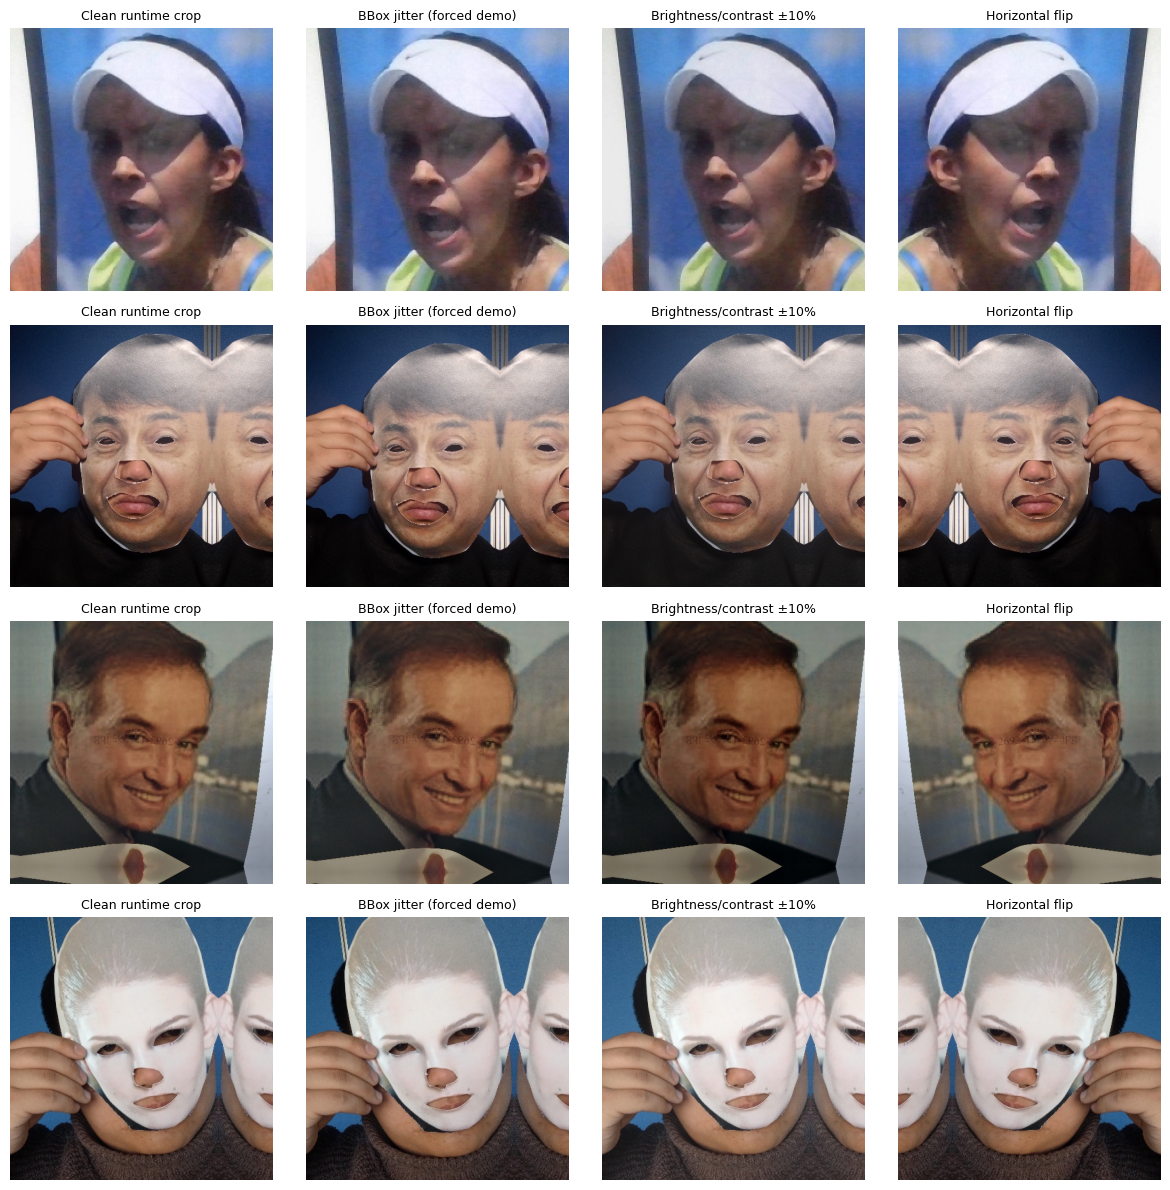

Training probabilities:
  Horizontal flip       : p=0.50
  Brightness/contrast   : p=0.30, limits ±10%
  BBox scale/translation: p=0.20, scale=(0.95, 1.05), translate=±5% face size
  Blur/JPEG/erase/rotation/perspective/hue/saturation: disabled


In [4]:
# Optional visual audit: compare clean crop with forced examples of each *configured* mild augmentation.
# This is diagnostic only; training still uses p=0.50 flip, p=0.30 appearance, p=0.20 bbox jitter.
RUN_AUGMENTATION_AUDIT = True
AUGMENTATION_AUDIT_SAMPLES = 4

if RUN_AUGMENTATION_AUDIT:
    audit_rng = np.random.default_rng(SAMPLE_SEED)
    audit_keys = audit_rng.choice(train_keys, size=min(AUGMENTATION_AUDIT_SAMPLES, len(train_keys)), replace=False)
    forced_photo = A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=1.0)

    fig, axes = plt.subplots(len(audit_keys), 4, figsize=(12, 3 * len(audit_keys)))
    axes = np.atleast_2d(axes)
    for r, k in enumerate(audit_keys):
        img_path = os.path.join(DATA_ROOT, k)
        clean = read_expanded_face_crop_rgb(img_path, bbox_jitter=False, strict=True)
        jittered = read_expanded_face_crop_rgb(
            img_path, bbox_jitter=True, bbox_jitter_p=1.0,
            jitter_scale=BBOX_JITTER_SCALE, jitter_translate=BBOX_JITTER_TRANSLATE, strict=True
        )
        photo = forced_photo(image=clean)["image"]
        flipped = np.ascontiguousarray(clean[:, ::-1])
        images = [clean, jittered, photo, flipped]
        titles = ["Clean runtime crop", "BBox jitter (forced demo)", "Brightness/contrast ±10%", "Horizontal flip"]
        for c, (im, title) in enumerate(zip(images, titles)):
            axes[r, c].imshow(im)
            axes[r, c].set_title(title, fontsize=9)
            axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()

    print("Training probabilities:")
    print(f"  Horizontal flip       : p=0.50")
    print(f"  Brightness/contrast   : p=0.30, limits ±10%")
    print(f"  BBox scale/translation: p={BBOX_JITTER_P:.2f}, scale={BBOX_JITTER_SCALE}, translate=±{BBOX_JITTER_TRANSLATE*100:.0f}% face size")
    print("  Blur/JPEG/erase/rotation/perspective/hue/saturation: disabled")


# Cell 4: MobileNetV3-Large Spatial Baseline (E1)

E1 tạo **256-D spatial feature** rồi MLP 128-D để phân loại 3 lớp. E3 sau này giữ nguyên spatial pathway này và chỉ thêm Frequency 64-D + fusion.

Training recipe v5 tối ưu khả năng hội tụ mà vẫn giữ baseline sạch:

- ImageNet-pretrained MobileNetV3-Large;
- AdamW, differential LR `1e-5` backbone / `1e-4` head;
- batch size 64;
- warmup 2 epochs rồi cosine decay, **preserve LR ratio 1:10**;
- max 30 epochs, early-stop theo Validation ACER;
- gradient clip `max_norm=5`;
- label smoothing 0.1, dropout 0.2 giữ nguyên để không thay quá nhiều yếu tố cùng lúc.


In [5]:
# Cell 4: Model Setup — optimized spatial-only E1 (no gamma in train/eval)
EPOCHS = 24
BACKBONE_LR = 1e-5
HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4

# Warmup + cosine use a SHARED multiplicative factor, so backbone:head LR stays 1:10.
WARMUP_EPOCHS = 2
WARMUP_START_FACTOR = 0.20
MIN_LR_FACTOR = 0.10

EARLY_STOP_PATIENCE = 4
EARLY_STOP_MIN_DELTA = 1e-4   # absolute ACER = 0.01 percentage point
EARLY_STOP_MIN_EPOCHS = 10     # avoid stopping during early fine-tuning/warmup dynamics
GRAD_CLIP_NORM = 5.0

PROTOCOL_VERSION = "spatial_e1_optimized_v5_1_time_balanced"

DROPOUT_RATE = 0.20
NUM_CLASSES = 3
SPATIAL_DIM = 256
HIDDEN_DIM = 128
LABEL_SMOOTHING = 0.10


class AntiSpoofMobileNetV3(nn.Module):
    def __init__(self, dropout_rate=DROPOUT_RATE, num_classes=NUM_CLASSES,
                 spatial_dim=SPATIAL_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        weights = models.MobileNet_V3_Large_Weights.DEFAULT
        backbone = models.mobilenet_v3_large(weights=weights)

        self.features = backbone.features
        self.avgpool = backbone.avgpool
        backbone_dim = backbone.classifier[0].in_features  # 960 for MNV3-Large

        self.spatial_projection = nn.Sequential(
            nn.Linear(backbone_dim, spatial_dim),
            nn.BatchNorm1d(spatial_dim),
            nn.Hardswish(inplace=True),
            nn.Dropout(dropout_rate),
        )
        self.classifier = nn.Sequential(
            nn.Linear(spatial_dim, hidden_dim),
            nn.Hardswish(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward_features(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.spatial_projection(x)

    def forward(self, x):
        return self.classifier(self.forward_features(x))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AntiSpoofMobileNetV3().to(device)

# Equal class weights remain intentional. Threshold calibration handles the binary operating point;
# class reweighting/focal loss would be a separate experiment rather than a hidden baseline trick.
class_weights = torch.ones(NUM_CLASSES, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.AdamW(
    [
        {"params": model.features.parameters(), "lr": BACKBONE_LR, "name": "backbone"},
        {"params": model.spatial_projection.parameters(), "lr": HEAD_LR, "name": "spatial_projection"},
        {"params": model.classifier.parameters(), "lr": HEAD_LR, "name": "classifier"},
    ],
    weight_decay=WEIGHT_DECAY,
)


def lr_multiplier(epoch_index: int) -> float:
    """2 warmup epochs, then cosine decay to MIN_LR_FACTOR at the final epoch."""
    epoch_index = int(epoch_index)
    if WARMUP_EPOCHS > 0 and epoch_index < WARMUP_EPOCHS:
        # epoch 0 -> 0.20, epoch 1 -> 0.60; epoch 2 starts at full LR.
        return WARMUP_START_FACTOR + (1.0 - WARMUP_START_FACTOR) * (epoch_index / WARMUP_EPOCHS)

    cosine_epochs = max(1, EPOCHS - WARMUP_EPOCHS)
    # Epoch WARMUP_EPOCHS starts at progress 0; final epoch reaches progress 1.
    denom = max(1, cosine_epochs - 1)
    progress = min(1.0, max(0.0, (epoch_index - WARMUP_EPOCHS) / denom))
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return MIN_LR_FACTOR + (1.0 - MIN_LR_FACTOR) * cosine


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_multiplier)

amp_enabled = (device.type == "cuda")
try:
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

print(model)
print("Device:", device)
print("Protocol:", PROTOCOL_VERSION)
print("Run mode:", RUN_MODE)
print("Max epochs:", EPOCHS, "| early-stop patience:", EARLY_STOP_PATIENCE, "| earliest stop epoch:", EARLY_STOP_MIN_EPOCHS)
print("Base/max LRs:", {"backbone": BACKBONE_LR, "head": HEAD_LR})
print("Initial warmup LRs:", [g["lr"] for g in optimizer.param_groups])
print("Final LR targets:", {"backbone": BACKBONE_LR * MIN_LR_FACTOR,
                              "head": HEAD_LR * MIN_LR_FACTOR})
print("LR ratio head/backbone preserved:", HEAD_LR / BACKBONE_LR)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 122MB/s] 


AntiSpoofMobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(

## Optional sanity check — inspect metadata

Cell này chỉ để kiểm tra cấu trúc metadata, không tham gia train/evaluation.


In [6]:
with open(TRAIN_JSON, 'r') as f:
    data = json.load(f)

keys = list(data.keys())
print("Tổng số ảnh metadata train:", len(keys))
print("--- 2 key đầu tiên ---")
for k in keys[:2]:
    print("KEY:", k)
    print("SUBJECT:", subject_id_from_relpath(k))
    print("3-CLASS LABEL:", label_of(data[k]))
    print("VALUE LEN:", len(data[k]))
    print(data[k])
    print()


Tổng số ảnh metadata train: 494405
--- 2 key đầu tiên ---
KEY: Data/train/2623/live/000000.jpg
SUBJECT: 2623
3-CLASS LABEL: 0
VALUE LEN: 44
[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0]

KEY: Data/train/5489/spoof/000001.jpg
SUBJECT: 5489
3-CLASS LABEL: 1
VALUE LEN: 44
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 1, 1, 1]



## Optional sanity check — inspect one bbox and crop


Ảnh tồn tại: True
BB.txt tồn tại: True
Nội dung BB.txt:
77 11 48 59 0.9962846

Ảnh gốc (H, W): (550, 500)
Crop 1.5x + REFLECT_101 (H, W): (217, 217)


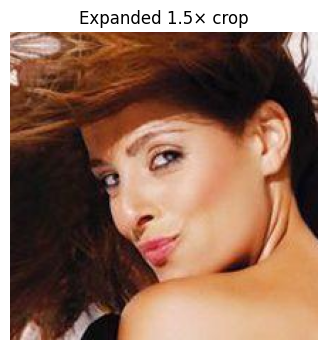

In [7]:
sample_key = keys[0]
img_path = os.path.join(DATA_ROOT, sample_key)
bb_path = os.path.splitext(img_path)[0] + "_BB.txt"

print("Ảnh tồn tại:", os.path.exists(img_path))
print("BB.txt tồn tại:", os.path.exists(bb_path))
if os.path.exists(bb_path):
    print("Nội dung BB.txt:")
    print(open(bb_path).read())

img_bgr = cv2.imread(img_path)
print("Ảnh gốc (H, W):", img_bgr.shape[:2] if img_bgr is not None else "Không đọc được")

crop_rgb = read_expanded_face_crop_rgb(img_path, expansion_factor=BBOX_EXPANSION_FACTOR, strict=True)
print("Crop 1.5x + REFLECT_101 (H, W):", crop_rgb.shape[:2])
plt.figure(figsize=(4, 4))
plt.imshow(crop_rgb)
plt.axis('off')
plt.title('Expanded 1.5× crop')
plt.show()


# Cell 5: Optimized training + validation calibration + robust checkpoint/resume

Checkpoint selection và threshold calibration chỉ dùng **subject-disjoint Validation**.

Binary PAD score giống production predictor:

```text
pad_score = real_logit - logsumexp([physical_spoof_logit, digital_spoof_logit])
Real iff pad_score >= logit_threshold
```

Training v5 bổ sung:

```text
Batch 64
2-epoch LR warmup
Cosine decay preserving backbone:head LR ratio 1:10
Max 30 epochs
Early stopping on Validation ACER
Gradient clipping after AMP unscale
```

`AntiSpoofPredictor.threshold` nhận **probability threshold**, nên notebook lưu cả raw logit threshold và `sigmoid(logit_threshold)`.

Gamma không dùng trong research train/validation/test. Nếu bật gamma lúc deployment, calibrate threshold deployment riêng trên Validation.


Saved run config: mnv3_e1_preliminary_v5_1_run_config.json
No compatible checkpoint -> training from ImageNet initialization
Max optimizer-step budget: 18,768 vs v4 reference 15,640 (1.20×; early stopping can reduce this).


Epoch 1/24 [Train]: 100%|██████████| 782/782 [28:10<00:00,  2.16s/it, acc3=0.8328, loss=0.6348]


⭐ New best: epoch=1, Val ACER=1.221%, APCER=1.559%, BPCER=0.884%, logit_thr=-0.771378, predictor_p=0.316181
Epoch 1: train_loss=0.6348, train_acc3=83.28% | val_loss=0.4518, val_acc3=92.23% | APCER=1.56%, BPCER=0.88%, ACER=1.22%, AUC=99.89% | logit_thr=-0.77138, predictor_p=0.31618 | grad_norm=0.932, no_improve=0/4


Epoch 2/24 [Train]: 100%|██████████| 782/782 [09:47<00:00,  1.33it/s, acc3=0.9369, loss=0.4263]


⭐ New best: epoch=2, Val ACER=0.447%, APCER=0.533%, BPCER=0.361%, logit_thr=-0.839315, predictor_p=0.301679
Epoch 2: train_loss=0.4263, train_acc3=93.69% | val_loss=0.3801, val_acc3=95.83% | APCER=0.53%, BPCER=0.36%, ACER=0.45%, AUC=99.98% | logit_thr=-0.83932, predictor_p=0.30168 | grad_norm=0.984, no_improve=0/4


...

⭐ New best: epoch=10, Val ACER=0.144%, APCER=0.168%, BPCER=0.120%, logit_thr=-0.682607, predictor_p=0.335680
Epoch 10: train_loss=0.3081, train_acc3=99.54% | val_loss=0.3172, val_acc3=98.70% | APCER=0.17%, BPCER=0.12%, ACER=0.14%, AUC=99.99% | logit_thr=-0.68261, predictor_p=0.33568 | grad_norm=0.593, no_improve=2/4


Epoch 11/24 [Train]: 100%|██████████| 782/782 [08:45<00:00,  1.49it/s, acc3=0.9959, loss=0.3065]


Epoch 11: train_loss=0.3065, train_acc3=99.59% | val_loss=0.3171, val_acc3=98.64% | APCER=0.13%, BPCER=0.18%, ACER=0.15%, AUC=99.99% | logit_thr=-0.29585, predictor_p=0.42657 | grad_norm=0.563, no_improve=3/4


Epoch 12/24 [Train]: 100%|██████████| 782/782 [09:01<00:00,  1.44it/s, acc3=0.9971, loss=0.3040]


Epoch 12: train_loss=0.3040, train_acc3=99.71% | val_loss=0.3175, val_acc3=98.62% | APCER=0.13%, BPCER=0.16%, ACER=0.14%, AUC=99.98% | logit_thr=-0.45064, predictor_p=0.38921 | grad_norm=0.497, no_improve=4/4
⏹️ Early stopping at epoch 12: no Validation ACER improvement > 0.000100 for 4 epochs.
Saved history: mnv3_e1_preliminary_v5_1_training_history.json


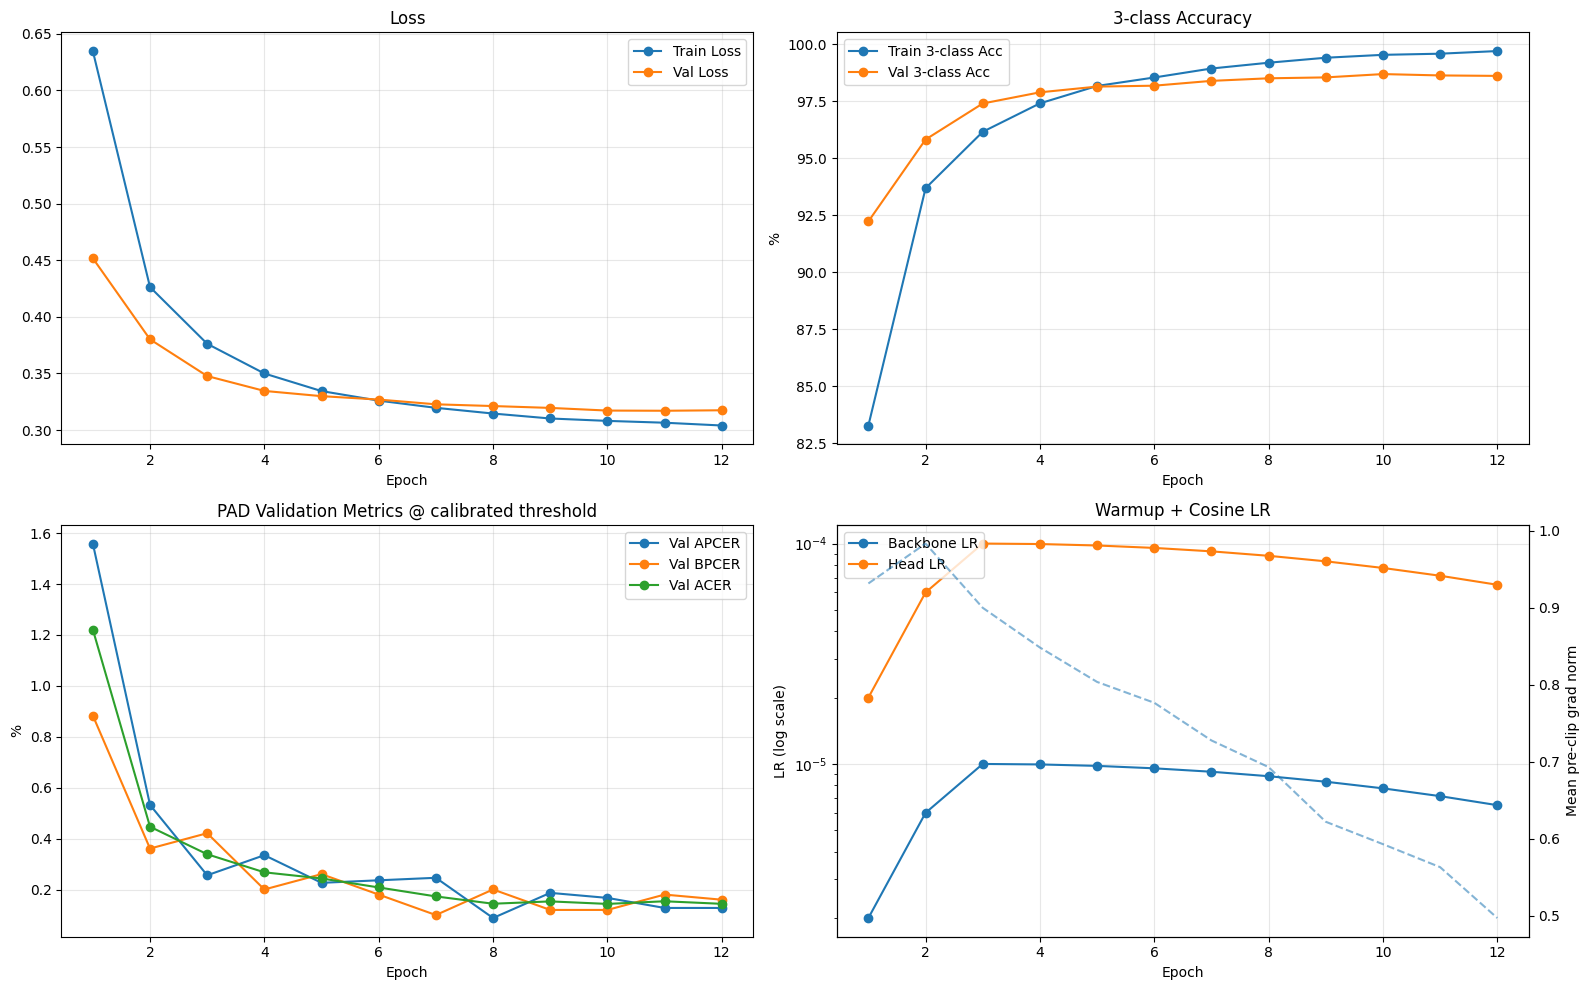

Best validation ACER: 0.144% at epoch 10
Locked logit threshold: -0.682607114315033
AntiSpoofPredictor probability threshold: 0.33567967
Best model: mnv3_e1_preliminary_v5_1_best.pth
Metadata : mnv3_e1_preliminary_v5_1_best_meta.json


In [8]:
# Cell 5: Training Loop — ACER checkpoint + production-compatible score/calibration + safe resume
RUN_NAME = f"mnv3_e1_{RUN_MODE}_v5_1"
CHECKPOINT_PATH = f"{RUN_NAME}_checkpoint_last.pth"
BEST_MODEL_PATH = f"{RUN_NAME}_best.pth"
BEST_META_PATH = f"{RUN_NAME}_best_meta.json"
HISTORY_PATH = f"{RUN_NAME}_training_history.json"
RUN_CONFIG_PATH = f"{RUN_NAME}_run_config.json"

# IMPORTANT: point only to a checkpoint produced by THIS protocol version.
CHECKPOINT_INPUT_PATH = ""  # e.g. "/kaggle/input/<previous-output>/checkpoint_last.pth"


def logits_to_pad_score(outputs):
    """
    Match AntiSpoofPredictor.process_with_logits():
        pad_score = real_logit - logsumexp(all_spoof_logits)
    This is exactly equivalent to logit(P_real / (1-P_real)) for a 3-class softmax model.
    """
    real_logit = outputs[:, 0]
    spoof_logsumexp = torch.logsumexp(outputs[:, 1:], dim=1)
    return real_logit - spoof_logsumexp


PREDICTOR_PROB_EPS = 1e-6
PREDICTOR_MIN_LOGIT_THRESHOLD = math.log(PREDICTOR_PROB_EPS / (1.0 - PREDICTOR_PROB_EPS))
PREDICTOR_MAX_LOGIT_THRESHOLD = -PREDICTOR_MIN_LOGIT_THRESHOLD


def probability_from_logit_threshold(t):
    """Stable sigmoid: converts calibrated pad-score threshold to AntiSpoofPredictor(threshold=p)."""
    t = float(t)
    if t >= 0:
        z = math.exp(-t)
        return 1.0 / (1.0 + z)
    z = math.exp(t)
    return z / (1.0 + z)


def calibrate_threshold_min_acer(pad_scores, binary_labels):
    """
    Score convention: d = real_logit - logsumexp(spoof_logits).
    Predict Real when d >= threshold, Spoof when d < threshold.
    Threshold is chosen on Validation ONLY by minimum ACER.
    Tie-break: lower APCER, then lower BPCER.
    """
    d = np.asarray(pad_scores, dtype=np.float64)
    y = np.asarray(binary_labels, dtype=np.int64)
    real_scores = np.sort(d[y == 0])
    spoof_scores = np.sort(d[y == 1])
    if len(real_scores) == 0 or len(spoof_scores) == 0:
        raise ValueError("Validation set must contain both Real and Spoof samples")
    if not np.all(np.isfinite(d)):
        raise ValueError("Non-finite PAD scores detected during validation")

    unique_scores = np.unique(d)
    thresholds = np.concatenate((
        [np.nextafter(unique_scores[0], -np.inf)],
        unique_scores,
        [np.nextafter(unique_scores[-1], np.inf)],
        [PREDICTOR_MIN_LOGIT_THRESHOLD, PREDICTOR_MAX_LOGIT_THRESHOLD],
    ))
    # Predictor clamps probability threshold to [1e-6, 1-1e-6]. Keep calibration
    # inside the exactly representable logit range so deployment decisions are identical.
    thresholds = np.unique(np.clip(
        thresholds, PREDICTOR_MIN_LOGIT_THRESHOLD, PREDICTOR_MAX_LOGIT_THRESHOLD
    ))

    # BPCER = Real -> Spoof = P(d < t | real)
    bpcer = np.searchsorted(real_scores, thresholds, side="left") / len(real_scores)
    # APCER = Spoof -> Real = P(d >= t | spoof)
    apcer = 1.0 - np.searchsorted(spoof_scores, thresholds, side="left") / len(spoof_scores)
    acer = 0.5 * (apcer + bpcer)

    # np.lexsort uses the LAST key as primary: ACER -> APCER -> BPCER.
    best_idx = np.lexsort((bpcer, apcer, acer))[0]
    logit_threshold = float(thresholds[best_idx])
    return {
        "logit_threshold": logit_threshold,
        "probability_threshold": probability_from_logit_threshold(logit_threshold),
        "APCER": float(apcer[best_idx]),
        "BPCER": float(bpcer[best_idx]),
        "ACER": float(acer[best_idx]),
    }


def metrics_from_scores(binary_labels, pad_scores, logit_threshold):
    y_true = np.asarray(binary_labels, dtype=np.int64)
    d = np.asarray(pad_scores, dtype=np.float64)
    y_pred = (d < logit_threshold).astype(np.int64)  # 0 Real, 1 Spoof
    spoof_score = -d  # larger => more spoof-like

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    # Positive class = Spoof.
    # APCER: attack (Spoof) accepted as Real => FN / all Spoof.
    apcer = FN / (FN + TP) if (FN + TP) else 0.0
    # BPCER: bona fide (Real) rejected as Spoof => FP / all Real.
    bpcer = FP / (TN + FP) if (TN + FP) else 0.0
    acer = 0.5 * (apcer + bpcer)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, spoof_score) if len(np.unique(y_true)) == 2 else float("nan")

    return {
        "Accuracy": float(acc),
        "APCER": float(apcer),
        "BPCER": float(bpcer),
        "ACER": float(acer),
        "AUC": float(auc),
        "confusion_matrix": cm.tolist(),
    }


def collect_validation(model, loader):
    model.eval()
    total_loss = 0.0
    total = 0
    correct_3class = 0
    all_binary_labels = []
    all_pad_scores = []

    with torch.inference_mode():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)

            bs = labels.size(0)
            total_loss += loss.item() * bs
            total += bs
            correct_3class += (outputs.argmax(dim=1) == labels).sum().item()

            d = logits_to_pad_score(outputs).detach().cpu().numpy()
            binary = (labels > 0).long().detach().cpu().numpy()
            all_pad_scores.append(d)
            all_binary_labels.append(binary)

    if total == 0:
        raise RuntimeError("Validation loader is empty")

    return {
        "loss": total_loss / total,
        "acc_3class": correct_3class / total,
        "pad_scores": np.concatenate(all_pad_scores),
        "binary_labels": np.concatenate(all_binary_labels),
    }


def cpu_state_dict(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def save_best_artifacts(best_state, best_epoch, best_val_metrics, best_logit_threshold):
    torch.save(best_state, BEST_MODEL_PATH)
    probability_threshold = probability_from_logit_threshold(best_logit_threshold)
    meta = {
        "protocol_version": PROTOCOL_VERSION,
        "best_epoch": int(best_epoch),
        "calibrated_logit_threshold": float(best_logit_threshold),
        "calibrated_probability_threshold": float(probability_threshold),
        "validation_metrics_percent": {
            k: (100.0 * float(v) if k in {"Accuracy", "APCER", "BPCER", "ACER", "AUC"} else v)
            for k, v in best_val_metrics.items()
            if k != "confusion_matrix"
        },
        "confusion_matrix": best_val_metrics["confusion_matrix"],
        "score_definition": "pad_score = real_logit - logsumexp([physical_spoof_logit, digital_spoof_logit]); Real iff pad_score >= logit_threshold",
        "predictor_contract": {
            "threshold_argument": float(probability_threshold),
            "apply_gamma": False,
            "color_order": "RGB",
            "model_img_size": INPUT_SIZE,
            "bbox_expansion_factor": BBOX_EXPANSION_FACTOR,
            "mean": CELEBA_MEAN,
            "std": CELEBA_STD,
        },
        "gamma_policy": "Research baseline is calibrated without gamma. If deployment uses apply_gamma=True, recalibrate a separate threshold on Validation under gamma preprocessing.",
        "train_samples": len(train_dataset),
        "val_samples": len(val_dataset),
        "test_samples_configured": len(test_dataset),
        "train_subjects": len(train_split_subjects),
        "val_subjects": len(val_split_subjects),
        "sample_seed": SAMPLE_SEED,
        "input_size": INPUT_SIZE,
        "bbox_expansion_factor": BBOX_EXPANSION_FACTOR,
        "normalization_mean": CELEBA_MEAN,
        "normalization_std": CELEBA_STD,
        "split_fingerprints": SPLIT_FINGERPRINTS,
    "split_manifest": SPLIT_MANIFEST_PATH,
    }
    with open(BEST_META_PATH, "w") as f:
        json.dump(meta, f, indent=2)


start_epoch = 0
best_val_acer = float("inf")
best_logit_threshold = None
best_epoch = -1
best_model_state = None
best_val_metrics = None
epochs_without_improvement = 0

RUN_CONFIG = {
    "protocol_version": PROTOCOL_VERSION,
    "epochs": EPOCHS,
    "backbone_lr": BACKBONE_LR,
    "head_lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "AdamW",
    "scheduler": "WarmupCosineLambdaLR",
    "warmup_epochs": WARMUP_EPOCHS,
    "warmup_start_factor": WARMUP_START_FACTOR,
    "min_lr_factor": MIN_LR_FACTOR,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "early_stop_min_delta": EARLY_STOP_MIN_DELTA,
    "early_stop_min_epochs": EARLY_STOP_MIN_EPOCHS,
    "grad_clip_norm": GRAD_CLIP_NORM,
    "strict_determinism": STRICT_DETERMINISM,
    "cudnn_benchmark": bool(torch.backends.cudnn.benchmark),
    "run_mode": RUN_MODE,
    "batch_size": BATCH_SIZE,
    "input_size": INPUT_SIZE,
    "bbox_expansion_factor": BBOX_EXPANSION_FACTOR,
    "normalization_mean": CELEBA_MEAN,
    "normalization_std": CELEBA_STD,
    "num_classes": NUM_CLASSES,
    "spatial_dim": SPATIAL_DIM,
    "hidden_dim": HIDDEN_DIM,
    "dropout_rate": DROPOUT_RATE,
    "label_smoothing": LABEL_SMOOTHING,
    "class_weights": [1.0, 1.0, 1.0],
    "train_sample_size": TRAIN_SAMPLE_SIZE,
    "val_target_size": VAL_SAMPLE_SIZE,
    "val_actual_size": len(val_dataset),
    "test_sample_size": TEST_SAMPLE_SIZE,
    "sample_seed": SAMPLE_SEED,
    "research_apply_gamma": False,
    "augmentation": {
        "horizontal_flip_p": 0.5,
        "brightness_limit": 0.10,
        "contrast_limit": 0.10,
        "appearance_p": 0.30,
        "bbox_jitter_p": BBOX_JITTER_P,
        "bbox_scale_jitter": list(BBOX_JITTER_SCALE),
        "bbox_translate_fraction": BBOX_JITTER_TRANSLATE,
        "affine_rotation": False,
    },
    "score_definition": "real_minus_logsumexp_spoof",
    "split_fingerprints": SPLIT_FINGERPRINTS,
    "split_manifest": SPLIT_MANIFEST_PATH,
}
with open(RUN_CONFIG_PATH, "w") as f:
    json.dump(RUN_CONFIG, f, indent=2)
print(f"Saved run config: {RUN_CONFIG_PATH}")

history = {
    "train_loss": [], "train_acc_3class": [],
    "val_loss": [], "val_acc_3class": [],
    "val_apcer": [], "val_bpcer": [], "val_acer": [], "val_auc": [],
    "val_logit_threshold": [], "val_probability_threshold": [],
    "lr_backbone": [], "lr_head": [], "grad_norm": [],
}

resume_source = None
if os.path.exists(CHECKPOINT_PATH):
    resume_source = CHECKPOINT_PATH
elif CHECKPOINT_INPUT_PATH and os.path.exists(CHECKPOINT_INPUT_PATH):
    shutil.copy(CHECKPOINT_INPUT_PATH, CHECKPOINT_PATH)
    resume_source = CHECKPOINT_PATH

if resume_source is not None:
    # Full research checkpoints contain optimizer/RNG Python objects -> weights_only=False is intentional.
    ckpt = safe_torch_load(resume_source, map_location=device, weights_only=False)
    ckpt_protocol = ckpt.get("protocol_version")
    if ckpt_protocol != PROTOCOL_VERSION:
        raise RuntimeError(
            f"Refusing incompatible checkpoint: protocol={ckpt_protocol!r}, expected={PROTOCOL_VERSION!r}. "
            "Do NOT resume from v1/v2 or leakage-affected runs."
        )

    ckpt_config = ckpt.get("config")
    if ckpt_config != RUN_CONFIG:
        raise RuntimeError(
            "Refusing checkpoint with a different run configuration/split.\n"
            f"checkpoint config={ckpt_config}\ncurrent config={RUN_CONFIG}"
        )

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    if "scaler_state" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state"])

    start_epoch = int(ckpt["epoch"]) + 1
    best_val_acer = float(ckpt["best_val_acer"])
    best_logit_threshold = ckpt.get("best_logit_threshold")
    best_epoch = int(ckpt.get("best_epoch", -1))
    best_model_state = ckpt.get("best_model_state")
    best_val_metrics = ckpt.get("best_val_metrics")
    epochs_without_improvement = int(ckpt.get("epochs_without_improvement", 0))
    history = ckpt["history"]

    if "loader_generator_state" in ckpt:
        loader_generator.set_state(ckpt["loader_generator_state"])
    if "torch_rng_state" in ckpt:
        torch.set_rng_state(ckpt["torch_rng_state"])
    if torch.cuda.is_available() and ckpt.get("cuda_rng_state_all") is not None:
        torch.cuda.set_rng_state_all(ckpt["cuda_rng_state_all"])
    if "numpy_rng_state" in ckpt:
        np.random.set_state(ckpt["numpy_rng_state"])
    if "python_rng_state" in ckpt:
        random.setstate(ckpt["python_rng_state"])

    # Re-create best artifacts in a new Kaggle session if only checkpoint_last was mounted.
    if best_model_state is not None and not os.path.exists(BEST_MODEL_PATH):
        torch.save(best_model_state, BEST_MODEL_PATH)
    if (best_model_state is not None and best_val_metrics is not None and best_logit_threshold is not None
            and not os.path.exists(BEST_META_PATH)):
        save_best_artifacts(best_model_state, best_epoch, best_val_metrics, best_logit_threshold)

    print(f"✅ Resume protocol v5.1 from epoch {start_epoch + 1}/{EPOCHS}; "
          f"best val ACER={best_val_acer*100:.3f}% @ epoch {best_epoch+1}")
else:
    print("No compatible checkpoint -> training from ImageNet initialization")

if start_epoch >= EPOCHS:
    print(f"🎉 Training already completed {EPOCHS} epochs.")

# Time-budget sanity check relative to v4 preliminary (100K, batch 128, 20 epochs).
if RUN_MODE == "preliminary":
    v4_ref_steps = math.ceil(100_000 / 128) * 20
    current_max_steps = len(train_loader) * EPOCHS
    print(f"Max optimizer-step budget: {current_max_steps:,} vs v4 reference {v4_ref_steps:,} "
          f"({current_max_steps / v4_ref_steps:.2f}×; early stopping can reduce this).")

for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    grad_norm_sum = 0.0
    grad_norm_steps = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        if hasattr(torch, "amp"):
            autocast_ctx = torch.amp.autocast(device_type=device.type, enabled=amp_enabled)
        else:
            autocast_ctx = torch.cuda.amp.autocast(enabled=amp_enabled)

        with autocast_ctx:
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        if torch.isfinite(grad_norm):
            grad_norm_sum += float(grad_norm.detach().cpu())
            grad_norm_steps += 1
        scaler.step(optimizer)
        scaler.update()

        bs = labels.size(0)
        running_loss += loss.item() * bs
        total += bs
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        pbar.set_postfix(loss=f"{running_loss/total:.4f}", acc3=f"{correct/total:.4f}")

    train_loss = running_loss / total
    train_acc = correct / total
    mean_grad_norm = grad_norm_sum / max(1, grad_norm_steps)

    # Validation is the ONLY source for checkpoint selection + threshold calibration.
    val = collect_validation(model, val_loader)
    cal = calibrate_threshold_min_acer(val["pad_scores"], val["binary_labels"])
    val_metrics = metrics_from_scores(
        val["binary_labels"], val["pad_scores"], cal["logit_threshold"]
    )

    history["train_loss"].append(train_loss)
    history["train_acc_3class"].append(train_acc)
    history["val_loss"].append(val["loss"])
    history["val_acc_3class"].append(val["acc_3class"])
    history["val_apcer"].append(val_metrics["APCER"])
    history["val_bpcer"].append(val_metrics["BPCER"])
    history["val_acer"].append(val_metrics["ACER"])
    history["val_auc"].append(val_metrics["AUC"])
    history["val_logit_threshold"].append(cal["logit_threshold"])
    history["val_probability_threshold"].append(cal["probability_threshold"])
    history["lr_backbone"].append(optimizer.param_groups[0]["lr"])
    history["lr_head"].append(optimizer.param_groups[1]["lr"])
    history["grad_norm"].append(mean_grad_norm)

    # Select checkpoint by Validation ACER. Tie-break by lower Validation APCER.
    current_acer = val_metrics["ACER"]
    current_apcer = val_metrics["APCER"]
    best_before_epoch = best_val_acer
    previous_best_apcer = float("inf")
    if best_epoch >= 0 and best_epoch < len(history["val_apcer"]):
        previous_best_apcer = history["val_apcer"][best_epoch]

    is_better = (
        current_acer < best_val_acer - 1e-12
        or (abs(current_acer - best_val_acer) <= 1e-12 and current_apcer < previous_best_apcer)
    )

    if is_better:
        best_val_acer = current_acer
        best_logit_threshold = float(cal["logit_threshold"])
        best_epoch = epoch
        best_model_state = cpu_state_dict(model)
        best_val_metrics = copy.deepcopy(val_metrics)
        save_best_artifacts(best_model_state, best_epoch, best_val_metrics, best_logit_threshold)
        print(
            f"⭐ New best: epoch={epoch+1}, Val ACER={current_acer*100:.3f}%, "
            f"APCER={current_apcer*100:.3f}%, BPCER={val_metrics['BPCER']*100:.3f}%, "
            f"logit_thr={best_logit_threshold:.6f}, "
            f"predictor_p={probability_from_logit_threshold(best_logit_threshold):.6f}"
        )

    # Early stopping requires a meaningful ACER improvement, not numerical noise.
    if current_acer < best_before_epoch - EARLY_STOP_MIN_DELTA:
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    scheduler.step()

    checkpoint = {
        "protocol_version": PROTOCOL_VERSION,
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "best_val_acer": best_val_acer,
        "best_logit_threshold": best_logit_threshold,
        "best_epoch": best_epoch,
        "best_model_state": best_model_state,
        "best_val_metrics": best_val_metrics,
        "epochs_without_improvement": epochs_without_improvement,
        "history": history,
        "loader_generator_state": loader_generator.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state_all": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        "numpy_rng_state": np.random.get_state(),
        "python_rng_state": random.getstate(),
        "config": RUN_CONFIG,
    }
    torch.save(checkpoint, CHECKPOINT_PATH)

    print(
        f"Epoch {epoch+1}: train_loss={train_loss:.4f}, train_acc3={train_acc*100:.2f}% | "
        f"val_loss={val['loss']:.4f}, val_acc3={val['acc_3class']*100:.2f}% | "
        f"APCER={val_metrics['APCER']*100:.2f}%, BPCER={val_metrics['BPCER']*100:.2f}%, "
        f"ACER={val_metrics['ACER']*100:.2f}%, AUC={val_metrics['AUC']*100:.2f}% | "
        f"logit_thr={cal['logit_threshold']:.5f}, predictor_p={cal['probability_threshold']:.5f} | "
        f"grad_norm={mean_grad_norm:.3f}, no_improve={epochs_without_improvement}/{EARLY_STOP_PATIENCE}"
    )

    if (epoch + 1 >= EARLY_STOP_MIN_EPOCHS
            and epochs_without_improvement >= EARLY_STOP_PATIENCE):
        print(f"⏹️ Early stopping at epoch {epoch+1}: no Validation ACER improvement > "
              f"{EARLY_STOP_MIN_DELTA:.6f} for {EARLY_STOP_PATIENCE} epochs.")
        break

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=2)
print(f"Saved history: {HISTORY_PATH}")

# Plot training history.
epoch_axis = np.arange(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(epoch_axis, history["train_loss"], label="Train Loss", marker='o')
axes[0,0].plot(epoch_axis, history["val_loss"], label="Val Loss", marker='o')
axes[0,0].set_title("Loss")
axes[0,0].set_xlabel("Epoch")
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(epoch_axis, np.array(history["train_acc_3class"]) * 100, label="Train 3-class Acc", marker='o')
axes[0,1].plot(epoch_axis, np.array(history["val_acc_3class"]) * 100, label="Val 3-class Acc", marker='o')
axes[0,1].set_title("3-class Accuracy")
axes[0,1].set_xlabel("Epoch"); axes[0,1].set_ylabel("%")
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(epoch_axis, np.array(history["val_apcer"]) * 100, label="Val APCER", marker='o')
axes[1,0].plot(epoch_axis, np.array(history["val_bpcer"]) * 100, label="Val BPCER", marker='o')
axes[1,0].plot(epoch_axis, np.array(history["val_acer"]) * 100, label="Val ACER", marker='o')
axes[1,0].set_title("PAD Validation Metrics @ calibrated threshold")
axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("%")
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(epoch_axis, history["lr_backbone"], label="Backbone LR", marker='o')
axes[1,1].plot(epoch_axis, history["lr_head"], label="Head LR", marker='o')
axes[1,1].set_yscale("log")
axes[1,1].set_title("Warmup + Cosine LR")
axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("LR (log scale)")
axes[1,1].legend(loc="upper left"); axes[1,1].grid(alpha=0.3)
ax2 = axes[1,1].twinx()
ax2.plot(epoch_axis, history["grad_norm"], linestyle='--', alpha=0.55, label="Grad norm")
ax2.set_ylabel("Mean pre-clip grad norm")

plt.tight_layout()
plt.savefig(f"{RUN_NAME}_training_history.png", dpi=160)
plt.show()

print(f"Best validation ACER: {best_val_acer*100:.3f}% at epoch {best_epoch+1}")
print(f"Locked logit threshold: {best_logit_threshold}")
print(f"AntiSpoofPredictor probability threshold: {probability_from_logit_threshold(best_logit_threshold):.8f}")
print(f"Best model: {BEST_MODEL_PATH}")
print(f"Metadata : {BEST_META_PATH}")


# Cell 6: Held-out Evaluation — intentionally gated

**Không calibration trên Test.** Để tránh human test-set tuning, v5.1 đặt:

```python
RUN_HELDOUT_TEST = False
RUN_EXTERNAL_SANITY = False
```

mặc định. Trong giai đoạn tuning/preliminary, hãy đọc **Validation metrics בלבד**.

Chỉ sau khi architecture + training protocol đã freeze mới bật held-out Test. Khi đó threshold vẫn là threshold đã khóa từ Validation.

Research profile dùng `apply_gamma=False`. Nếu production bật gamma, phải calibrate deployment threshold riêng trên Validation.


In [9]:
# Cell 6: Held-out in-domain test + optional external sanity check

def collect_scores(model, loader, name="Dataset"):
    model.eval()
    all_binary_labels = []
    all_pad_scores = []

    with torch.inference_mode():
        for images, labels in tqdm(loader, desc=f"Evaluating {name}"):
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            d = logits_to_pad_score(outputs).detach().cpu().numpy()
            binary = (labels > 0).long().numpy()
            all_pad_scores.append(d)
            all_binary_labels.append(binary)

    if not all_pad_scores:
        raise RuntimeError(f"{name} loader is empty")
    return np.concatenate(all_binary_labels), np.concatenate(all_pad_scores)


def evaluate_loader(model, loader, logit_threshold, name="Dataset"):
    y_true, d = collect_scores(model, loader, name=name)
    result = metrics_from_scores(y_true, d, logit_threshold)
    result["LogitThreshold"] = float(logit_threshold)
    result["PredictorProbabilityThreshold"] = probability_from_logit_threshold(logit_threshold)
    return result



RUN_HELDOUT_TEST = False
RUN_EXTERNAL_SANITY = False

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(f"Missing best model: {BEST_MODEL_PATH}")
if not os.path.exists(BEST_META_PATH):
    raise FileNotFoundError(f"Missing best metadata/threshold: {BEST_META_PATH}")

model.load_state_dict(safe_torch_load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
with open(BEST_META_PATH, 'r') as f:
    best_meta = json.load(f)

if best_meta.get("protocol_version") != PROTOCOL_VERSION:
    raise RuntimeError("Best metadata protocol does not match current notebook protocol")

locked_logit_threshold = float(best_meta["calibrated_logit_threshold"])
locked_probability_threshold = float(best_meta["calibrated_probability_threshold"])
print(f"Locked Validation logit threshold: {locked_logit_threshold:.6f}")
print(f"AntiSpoofPredictor(threshold=...): {locked_probability_threshold:.8f}")
print("Research inference profile: apply_gamma=False, color_order=RGB")
print(f"Best epoch: {best_meta['best_epoch'] + 1}")

if RUN_HELDOUT_TEST:
    test_results = evaluate_loader(
        model, test_loader,
        logit_threshold=locked_logit_threshold,
        name="CelebA-Spoof Held-out Test",
    )
    print("\nCelebA-Spoof Held-out Test")
    for k in ["Accuracy", "APCER", "BPCER", "ACER", "AUC"]:
        print(f"  {k:8s}: {test_results[k]*100:.3f}%")
    print("  Logit threshold:", test_results["LogitThreshold"])
    print("  Predictor p     :", test_results["PredictorProbabilityThreshold"])
    print("  CM [[TN,FP],[FN,TP]]:", test_results["confusion_matrix"])

    with open(f"{RUN_NAME}_heldout_test_results.json", "w") as f:
        json.dump({
            "protocol_version": PROTOCOL_VERSION,
            "run_mode": RUN_MODE,
            "test_size": len(test_dataset),
            "is_quick_test": TEST_SAMPLE_SIZE is not None,
            "research_apply_gamma": False,
            "locked_validation_logit_threshold": locked_logit_threshold,
            "predictor_probability_threshold": locked_probability_threshold,
            "metrics_percent": {k: test_results[k] * 100 for k in ["Accuracy", "APCER", "BPCER", "ACER", "AUC"]},
            "confusion_matrix": test_results["confusion_matrix"],
        }, f, indent=2)
else:
    test_results = None
    print("\n🔒 Held-out Test is disabled by default. Freeze the protocol first, then set RUN_HELDOUT_TEST=True.")

external_results = None
if RUN_EXTERNAL_SANITY:
    if "lcc_loader" in globals() and lcc_loader is not None:
        external_results = evaluate_loader(
            model, lcc_loader,
            logit_threshold=locked_logit_threshold,
            name="LCC-FASD External Sanity Check",
        )
        print("\nLCC-FASD External Sanity Check (same locked threshold; NO tuning)")
        for k in ["Accuracy", "APCER", "BPCER", "ACER", "AUC"]:
            print(f"  {k:8s}: {external_results[k]*100:.3f}%")
    else:
        print("\n⚠️ RUN_EXTERNAL_SANITY=True but lcc_loader is not defined; skipping.")
else:
    print("ℹ️ External sanity evaluation disabled.")

result_sets = []
if test_results is not None:
    result_sets.append(("CelebA Held-out", test_results))
if external_results is not None:
    result_sets.append(("LCC-FASD", external_results))

if result_sets:
    metrics = ["Accuracy", "APCER", "BPCER", "ACER", "AUC"]
    x = np.arange(len(metrics))
    width = 0.8 / len(result_sets)
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (label, results) in enumerate(result_sets):
        vals = [results[m] * 100 for m in metrics]
        offset = (i - (len(result_sets)-1)/2) * width
        bars = ax.bar(x + offset, vals, width, label=label)
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f"{h:.1f}", (bar.get_x()+bar.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)
    ax.set_ylabel("%")
    ax.set_title("PAD Evaluation @ Locked Validation Threshold (No-Gamma Research Profile)")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{RUN_NAME}_heldout_evaluation.png", dpi=160)
    plt.show()


Locked Validation logit threshold: -0.682607
AntiSpoofPredictor(threshold=...): 0.33567967
Research inference profile: apply_gamma=False, color_order=RGB
Best epoch: 10

🔒 Held-out Test is disabled by default. Freeze the protocol first, then set RUN_HELDOUT_TEST=True.
ℹ️ External sanity evaluation disabled.


# Cell 7: Export FP32 ONNX + PyTorch/ONNX parity + runtime contract

Export dùng best clean checkpoint v5. Output ONNX theo `RUN_NAME`; **không ghi đè** `best_model_quantized.onnx` của MiniFASNetV2SE production.

Cell đồng thời tạo runtime config. Với research baseline, `AntiSpoofPredictor` phải nhận:

```python
threshold=<calibrated_probability_threshold>
apply_gamma=False
color_order="RGB"
```

Sau khi chọn **official** model cuối cùng, có thể copy/rename artifact deploy thành `mnv3_large_3class_best.onnx` nếu muốn giữ naming production ổn định.


In [10]:
# Cell 7: Export FP32 ONNX + parity test + runtime config
if not ONNX_AVAILABLE:
    raise RuntimeError("onnx/onnxruntime unavailable. Install them before export.")
if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(f"Missing best clean checkpoint: {BEST_MODEL_PATH}")
if not os.path.exists(BEST_META_PATH):
    raise FileNotFoundError(f"Missing best metadata: {BEST_META_PATH}")

model.load_state_dict(safe_torch_load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
with open(BEST_META_PATH, 'r') as f:
    best_meta = json.load(f)

onnx_filename = f"{RUN_NAME}_best.onnx"
dummy_input = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE, device=device)

with torch.no_grad():
    torch_dummy_output = model(dummy_input).detach().cpu().numpy()

torch.onnx.export(
    model,
    dummy_input,
    onnx_filename,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"},
    },
)

onnx_model = onnx.load(onnx_filename)
onnx.checker.check_model(onnx_model)

# ORT parity on CPU to ensure exported graph matches PyTorch numerically.
session = ort.InferenceSession(onnx_filename, providers=["CPUExecutionProvider"])
ort_out = session.run(None, {session.get_inputs()[0].name: dummy_input.detach().cpu().numpy()})[0]
max_abs_diff = float(np.max(np.abs(torch_dummy_output - ort_out)))

print(f"✅ Exported FP32 ONNX: {onnx_filename}")
print(f"PyTorch/ONNX max |Δlogit| = {max_abs_diff:.8f}")
assert max_abs_diff < 1e-4, f"ONNX parity check failed: max_abs_diff={max_abs_diff}"

# Dynamic batch dimension.
batch4 = torch.randn(4, 3, INPUT_SIZE, INPUT_SIZE, device=device)
with torch.no_grad():
    pt4 = model(batch4).detach().cpu().numpy()
ort4 = session.run(None, {session.get_inputs()[0].name: batch4.detach().cpu().numpy()})[0]
batch4_diff = float(np.max(np.abs(pt4 - ort4)))
print(f"Dynamic batch=4 parity max |Δlogit| = {batch4_diff:.8f}")
assert batch4_diff < 1e-4

# Deployment/research runtime contract. Predictor's `threshold` argument is a probability.
runtime_config = {
    "protocol_version": PROTOCOL_VERSION,
    "model_file": onnx_filename,
    "model_img_size": INPUT_SIZE,
    "bbox_expansion_factor": BBOX_EXPANSION_FACTOR,
    "color_order": "RGB",
    "mean": CELEBA_MEAN,
    "std": CELEBA_STD,
    "apply_gamma": False,
    "score_definition": "pad_score = real_logit - logsumexp(all_spoof_logits)",
    "calibrated_logit_threshold": float(best_meta["calibrated_logit_threshold"]),
    "predictor_threshold_probability": float(best_meta["calibrated_probability_threshold"]),
    "predictor_example": "AntiSpoofPredictor(model_path='<exported_onnx_path>', threshold=<predictor_threshold_probability>, model_img_size=224, bbox_expansion_factor=1.5, mean=CELEBA_MEAN, std=CELEBA_STD, apply_gamma=False, color_order='RGB')",
    "gamma_note": "If apply_gamma=True is used in production, recalibrate a separate threshold on Validation using the gamma inference preprocessing. Do not reuse this no-gamma threshold.",
}
runtime_config_path = f"{RUN_NAME}_runtime_config.json"
with open(runtime_config_path, "w") as f:
    json.dump(runtime_config, f, indent=2)

print(f"✅ Saved runtime contract: {runtime_config_path}")
print(f"AntiSpoofPredictor threshold probability = {runtime_config['predictor_threshold_probability']:.8f}")
print("Research runtime requires apply_gamma=False")


ModuleNotFoundError: No module named 'onnxscript'